# NLP & Sentiment Analysis on Steam Game Reviews

<!-- # NLP & Sentiment Analysis on Steam Game Reviews -->

## 1. Setup

### 1.1 Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.feature_extraction.text import CountVectorizer


In [2]:
# Settings

pd.set_option('display.max_colwidth', 200)
sns.set_theme(style="darkgrid")

### 1.2 Load raw data

In [3]:
overview = pd.read_csv('../data/raw_data/steam_reviews.csv')

print(f'Overview data: {overview.shape}')

Overview data: (434891, 8)


## 2. First Overview (Orientation)

### 2.1 Shape & Info

In [4]:
overview.info()

<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   date_posted             434891 non-null  str  
 1   funny                   434891 non-null  int64
 2   helpful                 434891 non-null  int64
 3   hour_played             434891 non-null  int64
 4   is_early_access_review  434891 non-null  bool 
 5   recommendation          434891 non-null  str  
 6   review                  433375 non-null  str  
 7   title                   434891 non-null  str  
dtypes: bool(1), int64(3), str(4)
memory usage: 131.5 MB


In [5]:
overview.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt Capitulate France in order to get to Belgium&gt Get True Blitzkrieg achievementThis game is dad,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my opinion. I'd prefer playing the game with mods (historical accuracy so on) although the vanilla version is good aswell. 7/10,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is probably the most serious one I wrote. For starters the community of this game sucks just like every online game You don't wanna talk to them because the...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for fun not for competition so the DBD community doesn't really get to me. If I get a bad killer that face camps oh well. I die and move on to the next gam...,Dead by Daylight


In [6]:
print('Unique titles:', overview['title'].nunique())
print(overview['title'].value_counts())

Unique titles: 48
title
PLAYERUNKNOWN'S BATTLEGROUNDS                    145685
Grand Theft Auto V                                99956
Rust                                              71088
Rocket League®                                    67907
Dead by Daylight                                  22221
MONSTER HUNTER: WORLD                             18412
ASTRONEER                                          2661
The Elder Scrolls V: Skyrim Special Edition        1473
RESIDENT EVIL 2 / BIOHAZARD RE:2                   1385
Sid Meier’s Civilization® VI                        522
Euro Truck Simulator 2                              501
Terraria                                            260
Slay the Spire                                      260
Subnautica                                          247
Left 4 Dead 2                                       221
Insurgency: Sandstorm                               220
RimWorld                                            204
Garry's Mod             

In [7]:
print(overview[['title','review']].loc[856])

title                                    Dead by Daylight
review    the new update actully fixed this game a little
Name: 856, dtype: str


**Findings**

- The dataset contains 48 titles, but is dominated by a handful: top 5 ≈ 94% of all reviews, top 6 ≈ 98%. The remaining ~42 titles share
  ~2%, many with exactly 10 or 3 reviews (scraper sampling floor).
- Long tail of ~30% minor titles shares the remaining ~2%, many with exactly 10 or 3 reviews - a scraper sampling floor/cap, statistically negligible.
- The 6 major titles span very different genres (battle, open world, sports, horror, survival).

<!-- **Note:** Spotted missing titles in some rows during sample inspection. 
Will investigate in Section 3.2. -->

## 3. Type Conversion & Target

### 3.1 Convert data types

In [8]:
overview['date_posted'] = pd.to_datetime(overview['date_posted'], errors='coerce')

print('NaT in date_posted:', overview['date_posted'].isna().sum())

NaT in date_posted: 0


In [9]:
overview.info()

<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date_posted             434891 non-null  datetime64[us]
 1   funny                   434891 non-null  int64         
 2   helpful                 434891 non-null  int64         
 3   hour_played             434891 non-null  int64         
 4   is_early_access_review  434891 non-null  bool          
 5   recommendation          434891 non-null  str           
 6   review                  433375 non-null  str           
 7   title                   434891 non-null  str           
dtypes: bool(1), datetime64[us](1), int64(3), str(3)
memory usage: 127.4 MB


### 3.2 Create Label

In [10]:
overview['label'] = overview['recommendation'].map({
    'Recommended': 1,
    'Not Recommended': 0
})

print(overview['label'].value_counts(dropna=False))

label
1    303593
0    131298
Name: count, dtype: int64


In [11]:
overview.info()

<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date_posted             434891 non-null  datetime64[us]
 1   funny                   434891 non-null  int64         
 2   helpful                 434891 non-null  int64         
 3   hour_played             434891 non-null  int64         
 4   is_early_access_review  434891 non-null  bool          
 5   recommendation          434891 non-null  str           
 6   review                  433375 non-null  str           
 7   title                   434891 non-null  str           
 8   label                   434891 non-null  int64         
dtypes: bool(1), datetime64[us](1), int64(4), str(3)
memory usage: 130.7 MB


## 4 Metadata EDA

### 4.1 Class Balance (recommendation)

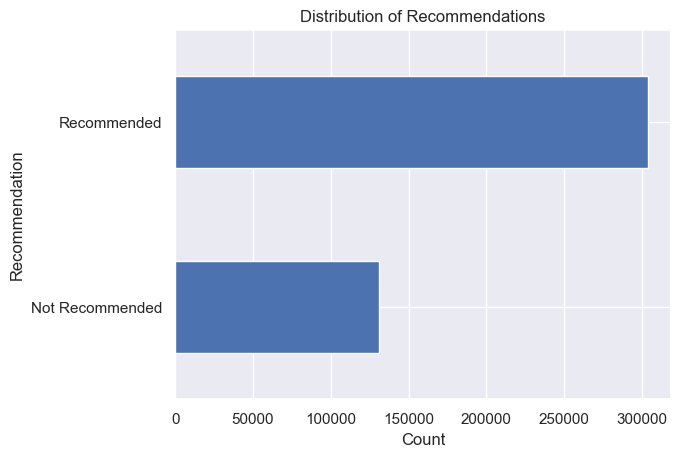

label
1    0.698
0    0.302
Name: proportion, dtype: float64


In [12]:
overview['recommendation'].value_counts(ascending=True).plot.barh()
plt.title('Distribution of Recommendations')
plt.xlabel('Count')
plt.ylabel('Recommendation')
plt.show()

print(overview['label'].value_counts(normalize=True).round(3))

### 4.2 Numeric Features (funny, helpful, hour_played)

**Goal**: 

Inspect the distribution of `funny`, `helpful`, and `hour_played`.
All three are count/duration features and are expected to be heavily right-skewed, so we plot them in a `logp1`scale for readability.
(`log1p(x) = log(1+x)` handles the many zeros that plain `log`cannot.)

> Note: This section only *diagnoses* the data. Any fix is recorded as a decision in a later Section (10)

In [13]:
overview[['funny', 'helpful', 'hour_played']].describe()

,funny,helpful,hour_played
count,4.348910e+05,434891.000000,434891.000000
mean,5.333024e+05,1.004114,364.130773
std,4.785640e+07,59.462935,545.961198
min,0.000000e+00,0.000000,0.000000
25%,0.000000e+00,0.000000,62.000000
50%,0.000000e+00,0.000000,190.000000
75%,0.000000e+00,0.000000,450.000000
max,4.294967e+09,28171.000000,31962.000000


In [14]:

MAX_VALID = 1_000_000   # real funny

poison_mask = overview['funny'] >= MAX_VALID
print('Invalid funny values (>= 1e6):', poison_mask.sum())
print(overview.loc[poison_mask, 'funny'].value_counts())

# Sanity check: helpful and hour_played are clean
print('helpful >= 1e6:', (overview['helpful'] >= MAX_VALID).sum())
print('hour_played >= 1e6:', (overview['hour_played'] >= MAX_VALID).sum())

Invalid funny values (>= 1e6): 54
funny
4294967295    48
4294967294     4
4294967288     1
4294967293     1
Name: count, dtype: int64
helpful >= 1e6: 0
hour_played >= 1e6: 0


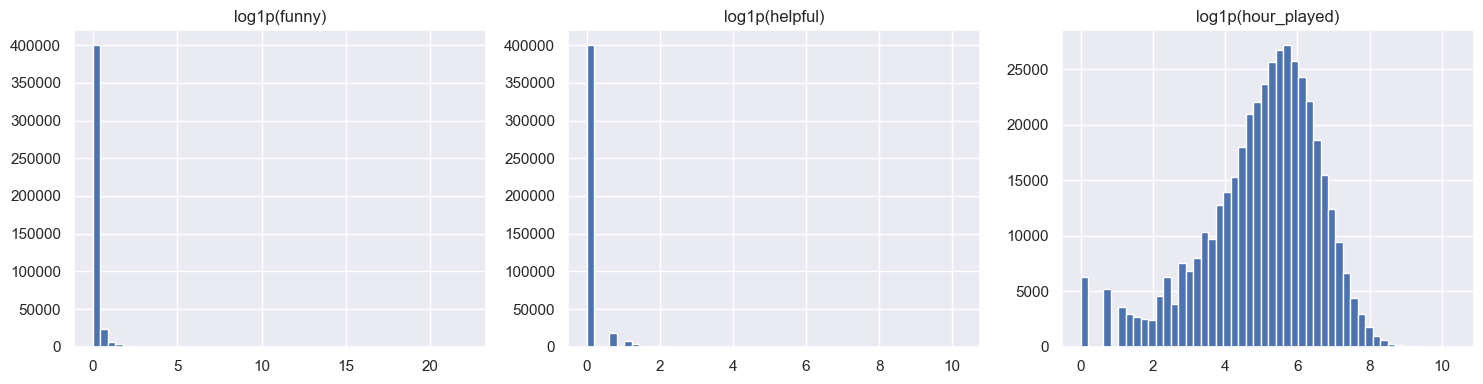

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['funny', 'helpful', 'hour_played']):
    series = overview[col]
    if col == 'funny':
        series = series[series != 4294967295]
    np.log1p(series).hist(bins=50, ax=ax)
    ax.set_title(f'log1p({col})')

plt.tight_layout()
plt.show()

**Findings**

- **`funny`** - Highly right-skewed. ~92% of reviews have `funny = 0`(399,656 of 434,891); the value drops off steeply afterwards.
*Data quality issue:* the column contains 54 corrupted values clustered
  just below 2^32: 4,294,967,295 (×48), 4,294,967,294 (×4), 4,294,967,293
  (×1), 4,294,967,288 (×1). The spread — not a single constant — indicates a
  signed-to-uint32 conversion artifact: small negatives (-1, -2, -7) wrapped
  around to ~4.29e9. These inflate the raw mean and std. Affects 54 rows
  (0.012%).

- **`helpful`** - Same right-skewed shape as `funny`: a large spike at 0 and a thin tail. 

- **`hour_played`** - Right-skewed but a smooth hump (no dominating zero-pile), median 190h, 75th pct 450h, max ~31,962h. The high max is plausible for long-term players. A minor spike near 0 reflects reviews written with little or no playtime.

### 4.3 Temporal & Flags (date_posted, is_early_access)

Time period: 2010-12-20 00:00:00 -> 2019-02-16 00:00:00


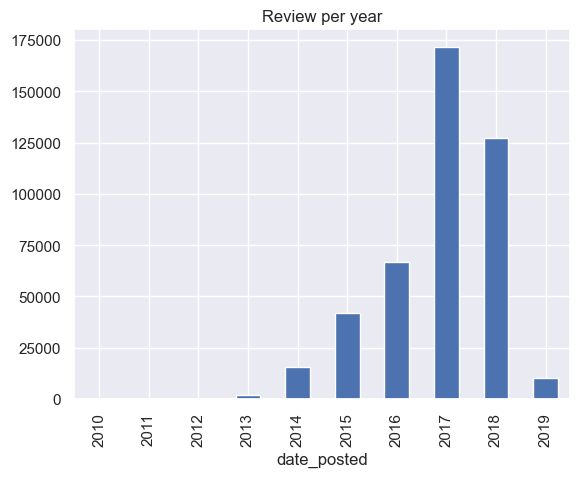

In [16]:
print('Time period:', overview['date_posted'].min(), '->', overview['date_posted'].max())

overview['date_posted'].dt.year.value_counts().sort_index().plot.bar()
plt.title('Review per year')
plt.show()

is_early_access_review
False    0.708
True     0.292
Name: proportion, dtype: float64


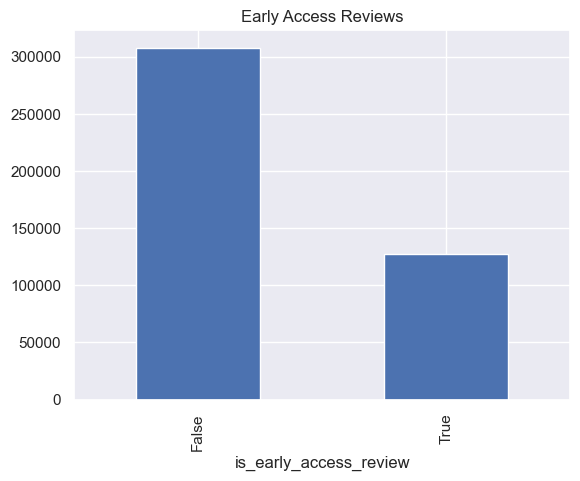

In [17]:
print(overview['is_early_access_review'].value_counts(normalize=True).round(3))

overview['is_early_access_review'].value_counts().plot.bar()
plt.title('Early Access Reviews')
plt.show()

**Findings**

- **`date_posted`** - Spans 2010-2019, heavily concentrated in 2016-2018 with a peak in 2017 with ~171k reviews. 2010-2012 is near-empty because Steam reviews launched late 2013. The sharp drop 2019 (~10k) is certainly a data-collection cutoff because it covers only ~6 weeks (data collection cutoff on Feb 16).

- **`is_early_access`** - ~29% True (127k) vs ~71% False (307k). Notably balanced (not a 99/1 flag), so it carries enough variation to be usable as a model feature. 

In [18]:
peak_2017 = overview[overview['date_posted'].dt.year == 2017]
print(peak_2017['title'].value_counts().head(10))
print('Share of top 5 titles in 2017:', 
      peak_2017['title'].value_counts().head(5).sum() / len(peak_2017))

title
PLAYERUNKNOWN'S BATTLEGROUNDS                    85220
Grand Theft Auto V                               43640
Rocket League®                                   18276
Rust                                             15360
Dead by Daylight                                  6553
ASTRONEER                                         1024
The Elder Scrolls V: Skyrim Special Edition        370
Sid Meier’s Civilization® VI                       177
Divinity: Original Sin 2 - Definitive Edition      142
Wallpaper Engine                                   114
Name: count, dtype: int64
Share of top 5 titles in 2017: 0.9853522341777317


### 4.4 Missing Values

In [19]:
missing_values = overview.isna().sum()
print(missing_values)

date_posted                  0
funny                        0
helpful                      0
hour_played                  0
is_early_access_review       0
recommendation               0
review                    1516
title                        0
label                        0
dtype: int64


In [20]:
# Checking for empty or whitespace-only reviews

empty_reviews = overview['review'].str.strip() == ''
print(f'Number of empty or whitespace-only reviews: {empty_reviews.sum()}')

Number of empty or whitespace-only reviews: 0


In [21]:
# Reviews, without any letters (only numbers, punctuation, or special characters)

no_letters = ~overview['review'].str.contains(r'[^\W\d_]', regex=True, na=False)
print("Reviews without any letters:", no_letters.sum())
print(overview.loc[no_letters, 'review'].value_counts().head(20))

Reviews without any letters: 8761
review
.                                                                                                                                                                                                                883
10/10                                                                                                                                                                                                            773
)                                                                                                                                                                                                                350
...                                                                                                                                                                                                              193
11/10                                                                                                      

### 4.5 Duplicates

In [22]:
print('Full duplicates:', overview.duplicated().sum())
print('Double Reviews:', overview.duplicated(subset=['review']).sum())

Full duplicates: 0
Double Reviews: 54979


In [23]:
dupes = overview.duplicated(subset='review', keep=False) # marks all 
overview[dupes]['review'].value_counts().head(20)

review
good game         1443
good              1283
.                  883
10/10              773
Good game          748
nice game          740
nice               649
Great game         581
great game         579
Good               530
Nice game          393
fun                390
yes                373
gg                 369
)                  350
Good Game          343
best game ever     330
&lt 3              320
Best game ever     312
Nice               309
Name: count, dtype: int64

## 5. Text Statistics

### 5.1 Length Features

In [24]:
overview['char_count'] = overview['review'].str.len()
overview['word_count'] = overview['review'].str.split().str.len()

### 5.2 Distributions

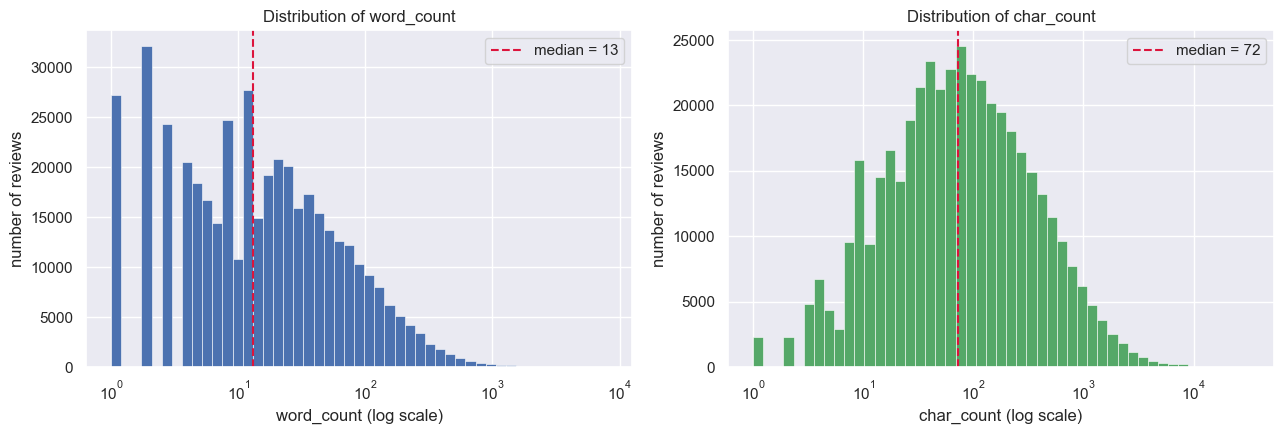

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, color in zip(axes, ['word_count', 'char_count'], ['#4C72B0', '#55A868']):
    data = overview[col].dropna()
    # log-spaced Bins
    bins = np.logspace(0, np.log10(data.max()), 50)
    ax.hist(data, bins=bins, color=color, edgecolor='white', linewidth=0.4)
    ax.set_xscale('log')
    median = data.median()
    ax.axvline(median, color='crimson', linestyle='--', linewidth=1.5,
               label=f'median = {median:.0f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(f'{col} (log scale)')
    ax.set_ylabel('number of reviews')
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
# Summary Statistics for Word and Character Counts

print(overview[['word_count', 'char_count']].describe())

          word_count     char_count
count  433375.000000  433375.000000
mean       40.542842     218.159905
std        87.019107     473.415958
min         1.000000       1.000000
25%         5.000000      25.000000
50%        13.000000      72.000000
75%        39.000000     211.000000
max      7984.000000   31949.000000


**Findings - length distribution (univariate)**

- Both `word_count`and `char_count` are strongly right-skewed: a dense bulk of short reviews and a long thin tail of very long ones (1000+ words).

- On the log scale, `word_count` shows distinct spikes at 1, 2, 3 words, the many ultra-short reviews ('good', '10/10'...) pile up on exact integer counts.

- confirms visually a large share of very short, low-content reviews.

### 5.3 Examples

In [27]:
# Largest Reviews

print(overview.nlargest(3, 'char_count')[['title', 'word_count', 'char_count']])

                                title  word_count  char_count
295854  PLAYERUNKNOWN'S BATTLEGROUNDS      7984.0     31949.0
354570  PLAYERUNKNOWN'S BATTLEGROUNDS      1514.0     10072.0
6678                 Dead by Daylight      1847.0      8000.0


In [28]:
longest = overview.nlargest(3, 'char_count')
for _, row in longest.iterrows():
    print('---', row['title'], '| words:', row['word_count'], '| chars:', row['char_count'])
    print(repr(row['review'][:300]))   # repr() show hidden characters
    print()

--- PLAYERUNKNOWN'S BATTLEGROUNDS | words: 7984.0 | chars: 31949.0
'Battlegrounds&gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt &gt'

--- PLAYERUNKNOWN'S BATTLEGROUNDS | words: 1514.0 | chars: 10072.0
'Solo&gt All Map&gt Play&gt Wating other player&gt Sit on airplane&gt Landing&gt Pick up random house&gt Lag.exe&gt Find Weapon&gt Find armor &gt Findbackpack&gt Go outside &gt Kill 0 4 &gt Get shoting at&gt Get headshot&gt Armor is break&gt Heal&gt Lag.exe&gt Friend chat&gt Close to crash.exe &gt De'

--- Dead by Daylight | words: 1847.0 | chars: 8000.0
'bad game do not buy because it is bad. bad game do not buy because it is bad. bad game do not buy because it is bad. bad game do not buy because it is bad. bad game do not buy because it is bad. bad game 

In [29]:
# Smallest Reviews

print(overview.nsmallest(5, 'word_count')[['title', 'word_count', 'review']])

                                          title  word_count      review
1   Expansion - Hearts of Iron IV: Man the Guns         1.0        yes.
17                             Dead by Daylight         1.0  reeeeeeeee
25                             Dead by Daylight         1.0        good
51                             Dead by Daylight         1.0          gg
56                             Dead by Daylight         1.0         yes


In [30]:
smallest = overview.nsmallest(3, 'word_count')
for _, row in smallest.iterrows():
    print('---', row['title'], '| words:', row['word_count'], '| chars:', row['char_count'])
    print(repr(row['review'][:300]))   # repr() show hidden characters
    print()

--- Expansion - Hearts of Iron IV: Man the Guns | words: 1.0 | chars: 4.0
'yes.'

--- Dead by Daylight | words: 1.0 | chars: 10.0
'reeeeeeeee'

--- Dead by Daylight | words: 1.0 | chars: 4.0
'good'



## 6. Language Check

**Goal:** Estimate the language distribution of the reviews. We need to know how multilingual the data is and how much an English-only filter would cost.

> Diagnosis on a sample now and a full-dataset detection in the cleaning step.

In [31]:
from langdetect import detect, DetectorFactory, detect_langs
DetectorFactory.seed = 42 # for reproducibility

sample_reviews = overview['review'].dropna().sample(5000, random_state = 42)

def lang_detect(text):
    try:
        return detect(text)
    except Exception:
        return 'unknown' # too short or empty letter reviews
    
langs = sample_reviews.apply(lang_detect)
print(langs.value_counts(normalize = True).round(3))

review
en         0.813
so         0.023
de         0.019
af         0.011
tl         0.010
no         0.009
da         0.008
unknown    0.007
cy         0.006
ro         0.006
pt         0.006
tr         0.006
es         0.005
pl         0.005
zh-cn      0.005
sw         0.005
fr         0.005
id         0.005
nl         0.005
it         0.004
et         0.004
vi         0.004
ca         0.003
hu         0.003
hr         0.003
sq         0.003
fi         0.002
sl         0.002
sv         0.002
ru         0.002
sk         0.001
ko         0.001
lv         0.001
lt         0.001
ja         0.001
cs         0.001
uk         0.000
th         0.000
el         0.000
he         0.000
ar         0.000
bg         0.000
Name: proportion, dtype: float64


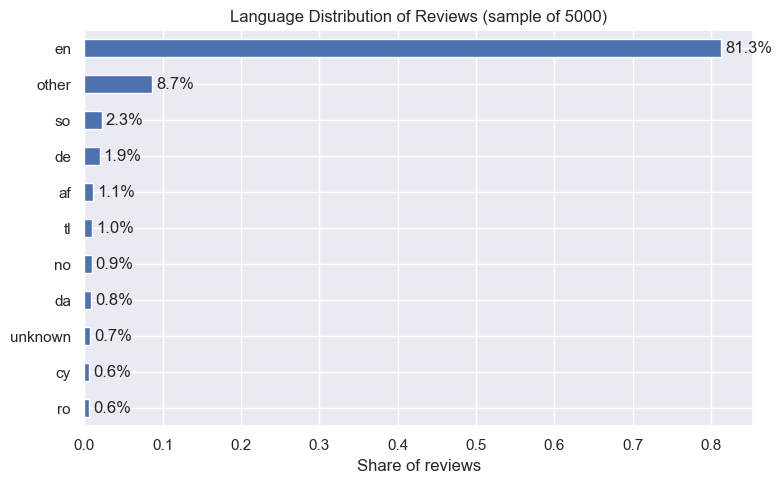

In [32]:
counts = langs.value_counts(normalize = True)

top = counts.head(10)
other = counts.iloc[10:].sum()
plot_data = pd.concat([top, pd.Series({'other': other})])

ax = plot_data.sort_values().plot.barh(figsize = (8,5), color = '#4C72B0')
ax.set_title('Language Distribution of Reviews (sample of 5000)')
ax.set_xlabel(('Share of reviews'))

for i, v in enumerate(plot_data.sort_values()):
    ax.text(v + 0.005, i, f'{v:.1%}', va = 'center')

plt.tight_layout()
plt.show()

In [33]:
df_lang_sample = overview.loc[sample_reviews.index].copy()

df_lang_sample['language'] = langs

for code in ['so', 'af', 'cy', 'tl', 'no']:
    print(f'--- Detected as {code} ---')
    sample_reviews = df_lang_sample.loc[df_lang_sample['language'] == code, 'review'].head(5)
    for text in sample_reviews:
        try:
            probs = detect_langs(text)
        except Exception:
            probs = 'n/a'
        print(f'Text: {text!r:60} -> Probabilities: {probs}')
    print()
    

--- Detected as so ---
Text: 'good'                                                       -> Probabilities: [so:0.9999974065657571]
Text: 'ye it good'                                                 -> Probabilities: [so:0.7142828902595582, en:0.14285877344989517, cy:0.1428567530260911]
Text: 'Good game'                                                  -> Probabilities: [so:0.9999985696972018]
Text: 'good'                                                       -> Probabilities: [so:0.9999974065657571]
Text: 'iha OK'                                                     -> Probabilities: [so:0.9999975775692043]

--- Detected as af ---
Text: 'ing Sucks!'                                                 -> Probabilities: [af:0.4285707465042493, tl:0.2857137961796562, en:0.14285908962160931, de:0.14285636746253508]
Text: 'Awesome'                                                    -> Probabilities: [af:0.9999951103983012]
Text: 'Awesome'                                                    -> Pr

In [34]:
from lingua import Language, LanguageDetectorBuilder

langs_set = [Language.ENGLISH, Language.GERMAN, Language.FRENCH, Language.SPANISH, Language.ITALIAN,
             Language.PORTUGUESE, Language.RUSSIAN, Language.POLISH,]
detector = LanguageDetectorBuilder.from_languages(*langs_set).build()

for text in ['good', 'ye it good', 'Good game', 'iha OK', 'Awesome', 'very good game']:
    conf = detector.compute_language_confidence_values(text)
    print(f'{text!r:20} -> ' + ', '.join(f'{c.language.name}:{c.value:.2f}' for c in conf))

'good'               -> ENGLISH:0.69, GERMAN:0.08, POLISH:0.07, SPANISH:0.06, FRENCH:0.04, ITALIAN:0.03, PORTUGUESE:0.03, RUSSIAN:0.00
'ye it good'         -> ENGLISH:0.46, GERMAN:0.13, FRENCH:0.12, SPANISH:0.10, ITALIAN:0.07, POLISH:0.07, PORTUGUESE:0.05, RUSSIAN:0.00
'Good game'          -> ENGLISH:0.50, PORTUGUESE:0.11, GERMAN:0.10, ITALIAN:0.09, SPANISH:0.08, FRENCH:0.07, POLISH:0.05, RUSSIAN:0.00
'iha OK'             -> POLISH:0.26, ENGLISH:0.21, GERMAN:0.20, ITALIAN:0.11, FRENCH:0.09, SPANISH:0.08, PORTUGUESE:0.04, RUSSIAN:0.00
'Awesome'            -> ENGLISH:0.86, GERMAN:0.04, PORTUGUESE:0.03, SPANISH:0.02, FRENCH:0.02, ITALIAN:0.02, POLISH:0.01, RUSSIAN:0.00
'very good game'     -> ENGLISH:0.72, POLISH:0.09, SPANISH:0.05, GERMAN:0.05, FRENCH:0.04, ITALIAN:0.03, PORTUGUESE:0.03, RUSSIAN:0.00


**Findings**

- English dominates with 81.3% as `en` on a 5000 review sample. The
  true share is higher — several exotic labels (`so` Somali 2.3%, `af`
  Afrikaans 1.1%, `cy` Welsh 0.6%, `tl` Tagalog 1.0%) are misclassified short
  English reviews, confirmed by manual inspection ("Good game", "Awesome",
  "FIX. YOUR. GAME.", "Gr8 m8 I r8 8/8").

- - `de` (German, ~1.9%) is the only plausibly genuine non-English group.


**Tool note - langdetect vs. lingua**

- langdetect fails badly on short reviews and reports false high confidence ("Good game" -> Somali 0.9999, "Awesome" -> Afrikaans 0.9999). Confidence is therefore useless as a filter criterion with langdetect.

- lingua with restriction on a specific language set classifies the same short reviews correctly and its confidence behaves much better.

## 7. Vocabulary & Frequencies

### 7.1 Top Words

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

texts = overview['review'].dropna()
vec = CountVectorizer()
dtm = vec.fit_transform(texts)

freqs = np.asarray(dtm.sum(axis=0)).ravel()
vocab = np.array(vec.get_feature_names_out())
order = freqs.argsort()[::-1] # reverse order

print(pd.Series(freqs[order[:25]], index = vocab[order[:25]]))

the     680683
game    507918
and     463976
to      442713
it      343173
you     319278
is      311375
of      287167
this    276482
for     191715
in      189932
with    163824
that    163344
but     151747
have    122574
on      121460
are     108545
not     101624
can      97354
fun      92910
if       92435
play     91639
be       88937
so       86421
my       84310
dtype: int64


**Findings**

- Raw top words are all stopwords ('the', 'and', 'to', 'it', 'is') -confirms stopwords removal is required before modeling.
- Domain-specific stopword candidates rank very high: 'game' (#2, 508k). These carry no discriminative power for game reviews and should be added to a custom stopword list.
- Vocabulary size: 221,024 unique tokens. Hapax (freq == 1): 148,123 = 67% of the vocabulary. Far above the typical 40-50%, driven by typos, slang, names, and concatenated junk typical of Steam reviews.
- Zipf's law holds (steep head, long flat tail at freq 1 on log-log).
- No HTML-entity remnants ('gt'/'amp') in the top 25 (they sit further down).

### 7.2 Vocab Size

Vocabulary size: 221024
Hapax legomena (words that appear only once): 148123
Share of hapax: 0.67


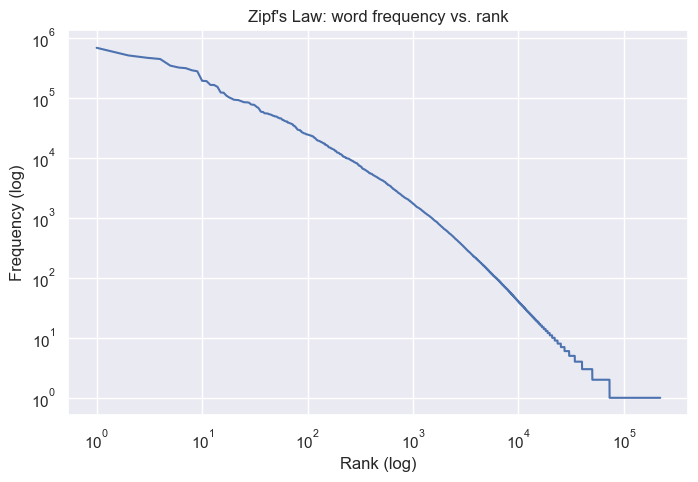

In [36]:
print('Vocabulary size:', len(vocab))
print('Hapax legomena (words that appear only once):', (freqs == 1).sum())
print('Share of hapax:', (freqs == 1).mean().round(3))

sorted_freqs = np.sort(freqs)[::-1]
ranks = np.arange(1, len(sorted_freqs) + 1)

plt.figure(figsize = (8,5))
plt.loglog(ranks, sorted_freqs)
plt.xlabel('Rank (log)')
plt.ylabel('Frequency (log)')
plt.title('Zipf\'s Law: word frequency vs. rank')
plt.show()

### 7.3 N-Grams

In [37]:
bigram_vec = CountVectorizer(ngram_range = (2,2), stop_words = 'english', min_df = 5) 
# min_df=5: only bigrams that appear in at least 5 reviews are included
bg = bigram_vec.fit_transform(texts)

bg_freqs = np.asarray(bg.sum(axis = 0)).ravel()
bg_vocab = np.array(bigram_vec.get_feature_names_out())
bg_order = bg_freqs.argsort()[::-1]

print(pd.Series(bg_freqs[bg_order[:20]], index = bg_vocab[bg_order[:20]]))

good game                          23431
great game                         22559
10 10                              17220
received free                      15895
product received                   15877
fun game                           13680
best game                          12114
play game                          11400
game fun                           10587
early access                       10481
love game                          10039
game play                           9886
single player                       9870
gt gt                               9750
buy game                            9558
play friends                        9149
recommend game                      8933
game just                           7724
game good                           7187
regionlockchina regionlockchina     7032
dtype: int64


In [38]:
with pd.option_context('display.max_colwidth', None):
    display(overview[overview['review'].str.contains('product received', case=False, na=False)].head(5))

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title,label,char_count,word_count
54,2016-12-17,0,0,1,False,Not Recommended,Product received for free. Played the free weekend problems with searching for a game in lobby with a friend gameplay is quite boring too from survivor side just fixing the engine and trying to hide the fact that most of the time the team isnt really helpful either. is not good in games like that. Graphic looks bad too and you cant really feel the atmoshpere of the horror.,Dead by Daylight,0,375.0,69.0
58,2018-11-02,0,0,228,False,Recommended,Product received for free. the game is good i recommened buying it when is 50 percent off,Dead by Daylight,1,89.0,17.0
71,2018-04-18,0,0,1261,False,Recommended,Product received for free. this game is so much fun with friends but the new system really makes it difficult to rank up but i myself have only been playing a few weeks not since launch such a thrilling fun multiplayer game though nonetheless,Dead by Daylight,1,242.0,44.0
112,2018-11-23,0,0,36,False,Recommended,Product received for free. Great gane with afriend nice design,Dead by Daylight,1,62.0,10.0
116,2018-04-14,0,0,261,False,Recommended,Product received for free. Pretty good job so far.,Dead by Daylight,1,50.0,9.0


In [39]:
print(overview[overview['review'].str.contains('product received', case=False, na=False)]['review'].iloc[0])

Product received for free. Played the free weekend problems with searching for a game in lobby with a friend gameplay is quite boring too from survivor side just fixing the engine and trying to hide the fact that most of the time the team isnt really helpful either. is not good in games like that. Graphic looks bad too and you cant really feel the atmoshpere of the horror.


In [40]:
doc_freq = np.asarray((dtm > 0).sum(axis=0)).ravel()   # in wie vielen Docs kommt jedes Wort vor

for k in [1, 2, 5, 10, 20, 50, 100]:
    kept = (doc_freq >= k).sum()
    print(f'min_df={k:>3}: {kept:>6} kept words, ' +
          f'({kept/len(doc_freq):.1%} of vocab)')

min_df=  1: 221024 kept words, (100.0% of vocab)
min_df=  2:  69262 kept words, (31.3% of vocab)
min_df=  5:  32593 kept words, (14.7% of vocab)
min_df= 10:  21023 kept words, (9.5% of vocab)
min_df= 20:  14052 kept words, (6.4% of vocab)
min_df= 50:   8529 kept words, (3.9% of vocab)
min_df=100:   5754 kept words, (2.6% of vocab)


**Findings**

- Sentiment phrases dominate: "good game", "great game", "fun game", "love
  game", "recommend game" — supports the positive-skew expectation and the
  value of bigrams for the sentiment model.
- "game" appears in most top bigrams -> confirms it as a domain stopword.
- Boilerplate detected: "product received" / "received free" (~31k combined)
  = remnants of Steam's "Product received for free" disclaimer. NOT
  user-written content -> remove in Section 10, else it forms a fake topic.
- HTML entity confirmed: "gt gt" (9.7k) = repeated "&gt;" from ASCII-art
  reviews (seen in 5.3) -> decode HTML entities in Section 10.
- Spam pattern: "regionlockchina regionlockchina" (7k) = repeated-token
  review-bombing.
- "10 10" (17k) = "10/10" split on the slash -> rating shorthand (cf. 8.2).
- No negations in the top bigrams because stop_words='english' removed "not"
  before pairing ("not good" -> "good"). Concrete evidence to EXCLUDE "not"
  from the stopword list for the sentiment pipeline.

## 8. Text Quality & Anomalies

**Goal:** Quantify the remaining text-quality phenomena before deciding on cleaning. Duplicates are covered in 4.3, letter-less reviews in 4.4. This section handles HTML entities, emojis, and repeated-token spam.
It's a diagnosis only, no data will be modified here. 

### 8.1 Special Chars, Emojis, ASCII-Art

In [41]:
# Checking for HTML entities in reviews
html_entities = overview['review'].str.contains(r'&(?:gt|lt|amp|quot|#\d+);?', regex = True, na = False)
print(f'Number of reviews with HTML entities: {html_entities.sum()}')
print(overview.loc[html_entities, 'review'].head(5).tolist())

Number of reviews with HTML entities: 9007
["&gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt Capitulate France in order to get to Belgium&gt Get True Blitzkrieg achievementThis game is dad", "Very fun game I gifted the game to my friends and now we play it together.This game consists about a player being the killer there are different killers and each of them have different abilities survivors have to fix the required amount of generators and find the escape or secret exit.Killers must find all the survivors and hang them until they die.Features You get to choose if you want to be killer or survivor which is an option I really like.You can customize your characters buy DLC's to have more things to wear on your characters and in some DLC's you will also get new characters such as killers or survivors.Character perks add ons and offerings You get to add items or power ups to your character + offerings that if you win grants you boosts.T

In [42]:
# Emojis
emoji_pattern = re.compile(
    "[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F000-\U0001F0FF]",
    flags=re.UNICODE,
)

has_emoji = overview['review'].str.contains(emoji_pattern, na=False)
print(f'Number of reviews with emojis: {has_emoji.sum()}')
print(overview.loc[has_emoji, 'review'].head(5).tolist())

Number of reviews with emojis: 0
[]


In [43]:
# Repeated-token spam

def repeated_token(text):
    tokens = str(text).split()
    if len(tokens) < 5:
        return 1.0
    return len(set(tokens)) / len(tokens)

sample_rep = overview['review'].dropna().sample(20000, random_state = 42)
rep = sample_rep.apply(repeated_token)
print('Reviews with < 20% unique tokens:', (rep < 0.2).sum())
print(overview.loc[rep[rep < 0.2].index, 'review'].head(5).tolist())

Reviews with < 20% unique tokens: 19
['OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL OMEGALUL', '&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt 3&lt

**Findings**
- HTML entities: 9,007 reviews affected, confirming the 'gt gt' bigram from 7.3. 
- Emojis: ~0 real Unicode emojis. Sentiment expressed as text emoticons like '<3' and ASCII, not Unicode -> no emoji handling needed.
- Repeated token spam: 19 in a 20k sample.

## 9. Text + Metadata

### 9.1 Review Length vs. Recommendation

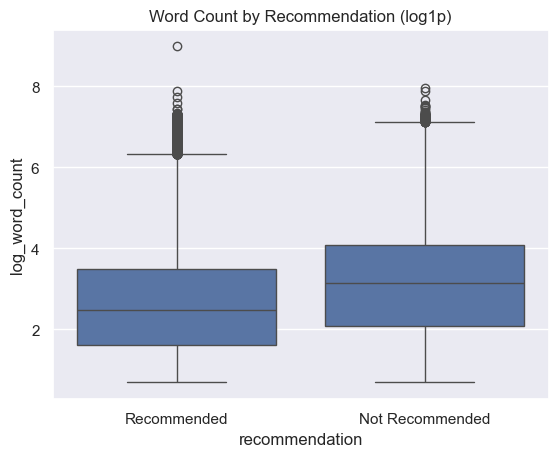

In [44]:
# Word Count Analysis

overview['log_word_count'] = np.log1p(overview['word_count'])

sns.boxplot(data=overview, x='recommendation', y='log_word_count')
plt.title('Word Count by Recommendation (log1p)')
plt.show()

In [45]:
print(overview.groupby('recommendation')['word_count'].describe())

                    count       mean         std  min  25%   50%   75%     max
recommendation                                                                
Not Recommended  130624.0  54.632273  101.960881  1.0  7.0  22.0  59.0  2895.0
Recommended      302751.0  34.463860   78.939523  1.0  4.0  11.0  32.0  7984.0


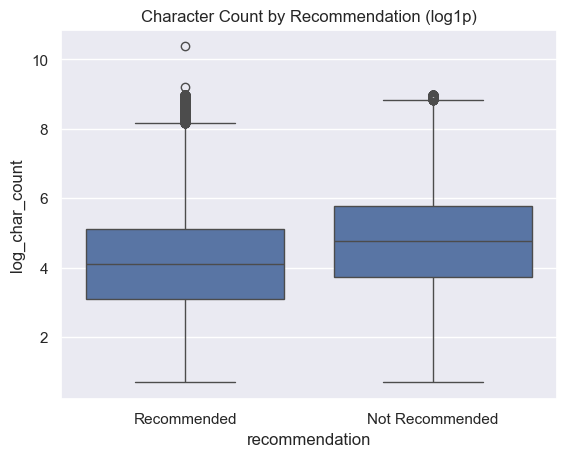

In [46]:
# Character Count Analysis

overview['log_char_count'] = np.log1p(overview['char_count'])

sns.boxplot(data=overview, x='recommendation', y='log_char_count')
plt.title('Character Count by Recommendation (log1p)')
plt.show()

In [47]:
print(overview.groupby('recommendation')['char_count'].describe())

                    count        mean         std  min   25%    50%    75%  \
recommendation                                                               
Not Recommended  130624.0  296.224384  557.109108  1.0  41.0  117.0  320.0   
Recommended      302751.0  184.478449  427.957414  1.0  21.0   59.0  167.0   

                     max  
recommendation            
Not Recommended   8000.0  
Recommended      31949.0  


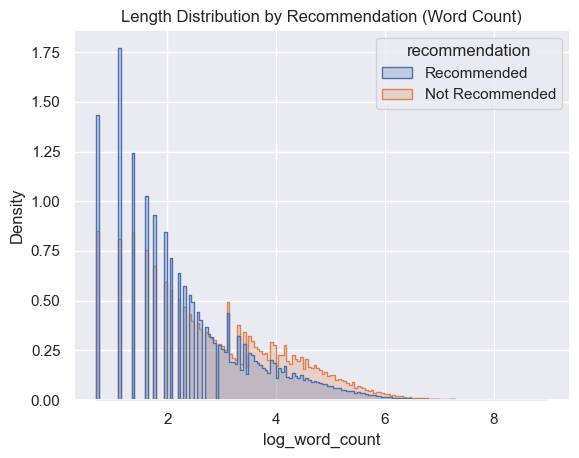

In [48]:
# Length Distribution by Recommendation (Word Count)

sns.histplot(data=overview, x='log_word_count', hue='recommendation',
             element='step', stat='density', common_norm=False)
plt.title('Length Distribution by Recommendation (Word Count)')
plt.show()

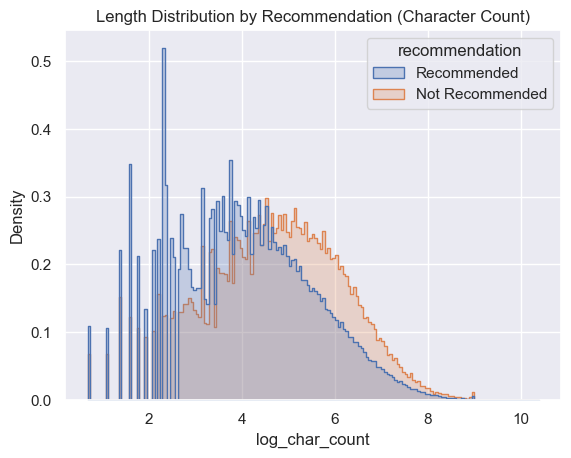

In [49]:
# Length Distribution by Recommendation (Character Count)

sns.histplot(data=overview, x='log_char_count', hue='recommendation',
             element='step', stat='density', common_norm=False)
plt.title('Length Distribution by Recommendation (Character Count)')
plt.show()

**Findings - review length vs. recommendation**

- Negative reviews are ~2x longer than positive ones: Not Recommended median 22 words (mean 54.6) vs Recommended median 11 words (mean 34.5). Same pattern in characters (117 vs 59 median).
- Interpretation: complaints need more words than praise ("love it" vs a detailed list of problems). Length may carry weak sentiment signal.
- Positive reviews dominate (~70%), so plots use per-group density normalization to compare shapes rather than raw counts.

### 9.2 Hour played vs. Recommendation

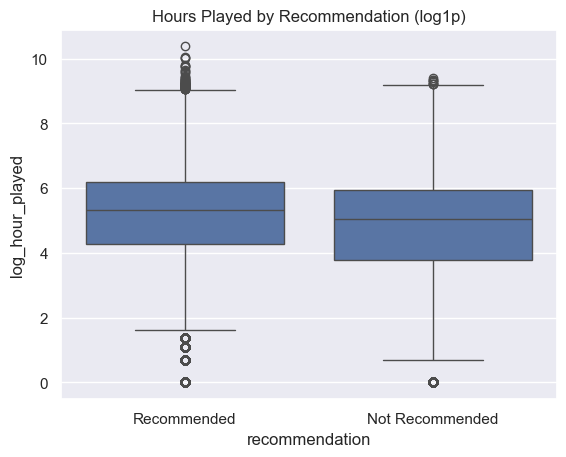

In [50]:
overview['log_hour_played'] = np.log1p(overview['hour_played'])

sns.boxplot(data=overview, x='recommendation', y='log_hour_played')
plt.title('Hours Played by Recommendation (log1p)') 
plt.show()

In [51]:
print(overview.groupby('recommendation')['hour_played'].describe())

                    count        mean         std  min   25%    50%    75%  \
recommendation                                                               
Not Recommended  131298.0  295.400851  438.597499  0.0  43.0  153.0  380.0   
Recommended      303593.0  393.855112  583.835271  0.0  71.0  207.0  484.0   

                     max  
recommendation            
Not Recommended  12113.0  
Recommended      31962.0  


**Findings**

- Recommenders played more, but the effect is moderate: median 207h vs. 153h for non-recommenders (mean 394h vs. 295h). The log scale boxplot understates this; the boxes overlap, but the median differ by ~35%.

- Both groups have median playtime >150h. Non-recommenders are not people who briefly tried the game, they invested a lot of time and still didn't like and rejected it (visible in the upper whisker).

- More hours may cause satisfaction, or prior investment may bias toward recommending (sunk cost).
Cannot be resolved from this data

- Both groups also include near-0.hour reviews (likely review-on-purchase or free key reviews).

### 9.3 Early access vs. Recommendation

label                          0         1
is_early_access_review                    
False                   0.329282  0.670718
True                    0.235544  0.764456


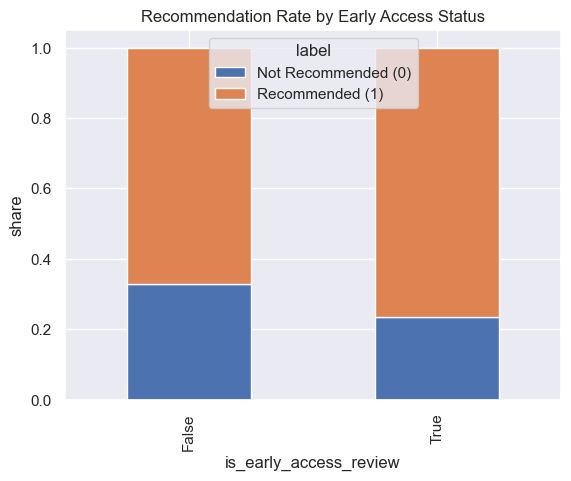

In [52]:
# Crosstab of recommendation by early access status

ct = pd.crosstab(overview['is_early_access_review'], overview['label'], normalize='index')
print(ct)

ct.plot.bar(stacked=True)
plt.title('Recommendation Rate by Early Access Status')
plt.ylabel('share')
plt.legend(title='label', labels=['Not Recommended (0)', 'Recommended (1)'], loc = 'upper center')
plt.show()

**Findings**

- Hypothesis: early access reviews are more critical - is rejected. The opposite holds. Early access reviews are 76.4% positive va. 67.1% for regular reviews.

- Interpretation: early access buyers are a self selected group of supporters who knowingly buy an unfinished game. 

- Effect size is both statistically significant and practically meaningful.

### 9.4 Engagement (helpful/funny) vs Length

In [53]:
clean = overview[overview['funny'] < MAX_VALID].copy()

print(clean[['word_count', 'funny', 'helpful']].corr(method = 'spearman'))

            word_count     funny   helpful
word_count    1.000000  0.040273  0.041024
funny         0.040273  1.000000  0.998750
helpful       0.041024  0.998750  1.000000


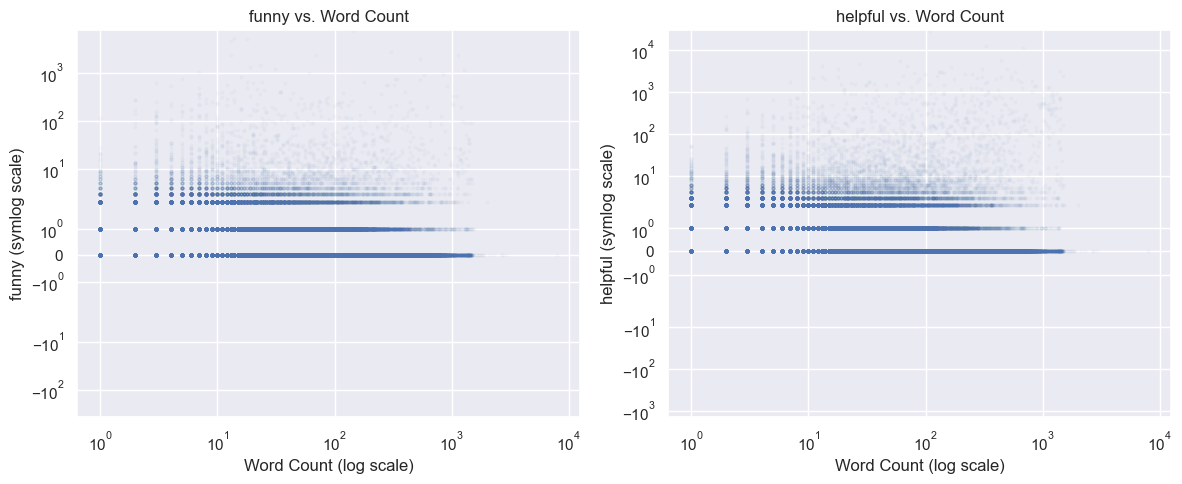

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, col in zip(axes, ['funny', 'helpful']):
    ax.scatter(clean['word_count'], clean[col], alpha=0.02, s=5)
    ax.set_xscale('log')
    ax.set_yscale('symlog')
    ax.set_xlabel('Word Count (log scale)')
    ax.set_ylabel(f'{col} (symlog scale)')
    ax.set_title(f'{col} vs. Word Count')

plt.tight_layout()
plt.show()

In [55]:
print(clean[['funny', 'helpful']].describe())
print((clean['funny'] == clean['helpful']).mean())   
print(clean[(clean['funny'] > 0) | (clean['helpful'] > 0)][['funny', 'helpful']].head(20))

               funny        helpful
count  434837.000000  434837.000000
mean        0.374828       1.003990
std        21.017025      59.466624
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000000       0.000000
max      7472.000000   28171.000000
0.9560386995586853
    funny  helpful
0       2        4
3     126     1086
4      85     2139
5       4       55
6      12      228
7     295      219
8       2       54
9     380      271
10     11      106
11     88      614
12    286      123
16      1        1
19      2        1
21      1        1
28      1        1
42      1        1
51      1        1
67      1        1
69      1        1
78      1        1


**Findings**

- Length barely correlates with engagement: Spearman ~0.04 for both word_count = helpful and word_count = funny. Longer reviews do not attract meaningfully more reactions.

- Interpretation: engagement is driven by visibility (time online, ranking position, popularity), not by review length or content.

- funny-helpful correlate at 0.999, but this is an artifact and not a real relationship. 95.6% of rows have identical values, because median and 75th percentile are 0 for both columns. The shared-zero mass dominates the rank correlation. Where either value is >0, the two columns diverge.


In [56]:
print((overview['funny'] > 1_000_000).sum())          # wie viele absurd grosse Werte insgesamt?
print(overview.loc[overview['funny'] > 1_000_000, 'funny'].value_counts())

54
funny
4294967295    48
4294967294     4
4294967288     1
4294967293     1
Name: count, dtype: int64


### 9.5 Top words vs. Sentiment

In [57]:

# clean uses the MAX_VALID threshold
data = clean.dropna(subset = ['review', 'label'])

vec = CountVectorizer(stop_words = 'english', min_df = 20)
dtm = vec.fit_transform(data['review'])
vocab = np.array(vec.get_feature_names_out())

is_pos = (data['label'] == 1).values

# share of reviews per class that contain a word (presence, not total frequency)
pos_rate = np.asarray((dtm[is_pos] > 0).mean(axis=0)).ravel()
neg_rate = np.asarray((dtm[~is_pos] > 0).mean(axis=0)).ravel()

diff = pos_rate - neg_rate   # positive = typical for Recommended, negative = typical for Not Recommended
order = diff.argsort()

print('=== Most POSITIVE words ===')
print(pd.Series(diff[order[::-1]][:20], index=vocab[order[::-1]][:20]).round(3))
print('\n=== Most NEGATIVE words ===')
print(pd.Series(diff[order][:20], index=vocab[order][:20]).round(3))


=== Most POSITIVE words ===
best         0.074
fun          0.071
good         0.068
great        0.063
10           0.048
friends      0.041
love         0.040
amazing      0.035
nice         0.030
awesome      0.029
received     0.015
survival     0.013
rocket       0.012
soccer       0.012
highly       0.012
product      0.011
cars         0.011
addictive    0.010
easy         0.010
league       0.009
dtype: float64

=== Most NEGATIVE words ===
money      -0.097
just       -0.074
buy        -0.064
don        -0.062
fix        -0.053
rockstar   -0.052
hackers    -0.050
mods       -0.050
modding    -0.048
bad        -0.044
ing        -0.042
dont       -0.041
player     -0.041
servers    -0.040
time       -0.040
want       -0.039
people     -0.037
banned     -0.037
players    -0.037
online     -0.035
dtype: float64


**Findings**

- Sentiment separates cleanly in the vocab -> strong signal, a TF-IDF + classifier should work well.

- Positive: best", "fun", "good", "great", "love", "amazing", "awesome",
  plus "10" (=10/10) and "friends"

- Negative reveals concrete complaint themes: value/money ("money", "buy",
  "fix"), and especially multiplayer frustration ("hackers", "banned",
  "servers", "online", "players")

- Game specific leakage: "rockstar"/"mods"/"modding" (negative),
  "rocket"/"soccer"/"cars"/"league"/"survival" (positive) are NOT sentiment
  words. They inherit their game's average rating.
  The model would learn game identity, not sentiment. -> add game-specific terms to stopwords.

-  Broken tokens: "don"/"dont" (= "don't" split on the apostrophe, appearing
  twice) and "ing" (a fragment). -> handle contractions consistently in
  preprocessing.

- Negations ("don", "dont") carry real negative signal -> do NOT strip "not"/
  negations for the sentiment pipeline.

## 10. Preprocessing Decisions

This section documents *what* preprocessing will be applied and *why*, based
on the EDA findings above. No data is modified here — the actual cleaning is
implemented separately in `02_preprocessing`.

Two variants are needed because the two goals have conflicting requirements:
- **Topic modeling (TF-IDF + LDA):** aggressive — remove stopwords, lemmatize,
  drop short reviews. Goal: clean, content-bearing tokens.
**Sentiment (TF-IDF + classifier):** more conservative — keep negations,
  keep short reviews. Goal: preserve sentiment signal.

### Shared cleaning (both variants)

| Step | Decision | Rationale (EDA finding) |
|---|---|---|
| HTML entities | Decode with `html.unescape` (HTML5 rules already cover `&gt` without `;`) | 8.1 — 9,007 reviews contain broken entities (`&gt` without `;`) |
| funny artifacts | Treat `funny >= MAX_VALID_FUNNY` (1e6) as invalid | 4.2 — 54 uint32 wrap-around values |
| Lowercasing | Yes | 7.1 — case variants split the vocabulary |
| Language filter | Keep English only; detect with lingua (restricted lang set), AFTER min-length filter | 6 — ~81%+ English; langdetect unreliable on short text |
| Contractions | Normalize ("don't"/"dont" -> consistent form) | 9.5 — "don"/"dont"/"ing" appear as broken tokens |

### Topic modeling variant (aggressive)

| Step | Decision | Rationale |
|---|---|---|
| Min length | Drop reviews < ~3 words | 5.2 / 8.2 — large mass of 1–2 word reviews carry no topic |
| Stopwords | English stopwords + domain terms (game, play, steam, ...) | 7.1 / 7.3 — "game" etc. rank top but carry no signal |
| Game-specific terms | Add to stopwords (rockstar, rocket, league, mods, ...) | 9.5 — these leak game identity into topics |
| Boilerplate | Remove "product received for free" | 7.3 — ~31k boilerplate bigrams |
| Lemmatization | Yes (spaCy, English model) | 7.2 — reduces inflection, shrinks vocab |
| min_df / max_df | min_df ~10–20, max_df to drop ubiquitous terms | 7.2 — 67% hapax; large vocab reduction |
| Duplicates | Drop duplicate review text | 4.5 — 54,979 duplicate texts distort topics |

### Sentiment variant (conservative)

| Step | Decision | Rationale |
|---|---|---|
| Min length | Keep short reviews (e.g. "10/10") | 8.2 / 9.5 — short reviews still carry sentiment |
| Negations | Do NOT strip "not"/"don't" | 9.5 — negations are strong negative signal |
| Stopwords | Standard list MINUS negations | 9.5 |
| n-grams | Use ngram_range=(1,2) in TF-IDF | 7.3 — phrases ("waste money", "not good") carry signal |
| min_df | Lower (~5) | keep rare-but-strong sentiment words ("refund", "unplayable") |
| Duplicates | Separate identical texts across train/test split | 4.5 — avoid leakage |
| Target | `label` (1/0); positive class ~70% | 4.1 — class imbalance -> stratify, weight, pick metric |